# SR Tutorial

2026 IAIFI Summer School

Tutorial lead: Jose M Munoz Arias

Professor: Miles Cranmer




# Encoding Physics Into the Search

We saw in the morning what symbolic regression is and how we can use evolutionary search to find equations that fit data. 

In this tutorial, we will focus on how to incorporate some of our physics bias into the search process and model building with the nice interface of PySR.

---

This notebook should be easy to run either on Colab or locally, and the only difference is that Colab will take a minute or two to compile the Julia backend the first time it is used. If you are running locally, make sure you have Julia installed and that PySR can find it. If you are running on Colab, you can just run the cell below to install PySR and its dependencies.

Lets do a bit of plumbing first for the notebook to work in both Colab and local environments.

In [1]:
# Run this before anything imports sympy.
#
# sympy >= 1.14 is a hard requirement.
import subprocess
import sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "pysr", "sympy>=1.14"], check=True)
    print("done; if the sympy check below fails, restart the runtime and re-run")
else:
    import sympy
    if sympy.__version__ < "1.14":
        raise RuntimeError(f"sympy >= 1.14 is required, found {sympy.__version__}")


In [2]:
import os
os.environ.setdefault("PYTHON_JULIACALL_THREADS", "auto")
os.environ.setdefault("PYTHON_JULIACALL_AUTOLOAD_IPYTHON_EXTENSION", "no")

import time
from pathlib import Path

import numpy as np
import pandas as pd
import sympy

t0 = time.time()
import pysr
from pysr import PySRRegressor, TemplateExpressionSpec
rng = np.random.default_rng(0)
print(f"pysr {pysr.__version__} imported in {time.time() - t0:.0f}s | sympy {sympy.__version__}")

REPO_URL = ("https://raw.githubusercontent.com/munozariasjm/"
            "sr_tutorial_material/master/01_tutorial")

try:
    from session1_data import *
    print("session1_data imported")
except ImportError:
    print("session1_data not found, downloading from GitHub")
    import urllib.request
    urllib.request.urlretrieve(f"{REPO_URL}/session1_data.py", "session1_data.py")
    from session1_data import *
    print("session1_data downloaded and imported")

ASSETS = Path("assets")

REPRO = dict(deterministic=True, parallelism="serial", verbosity=0, progress=False)

def kink(model):
    """The highest-`score` row, where loss drops most per unit of added complexity."""
    return model.equations_.loc[model.equations_.score.idxmax()]

pysr 1.5.10 imported in 105s | sympy 1.14.0
session1_data imported


## 0. Making sure everything runs

Lets make sure that we are able to run everything while we review the API:

In [6]:
X = 2 * rng.standard_normal((100, 5))
y = 2 * np.cos(X[:, 3]) + X[:, 0] ** 2 - 2

quick = PySRRegressor(binary_operators=["+", "-", "*", "/"],
                      unary_operators=["cos", "exp"],
                      niterations=30,
                      random_state=0,
                      **REPRO)
quick.fit(X, y)
quick.equations_[["complexity", "loss", "score", "equation"]]

,complexity,loss,score,equation
0,1,4.134850e+01,0.000000,3.155528
1,3,4.945579e+00,1.061771,x0 * x0
2,5,2.054053e+00,0.439340,(x0 * x0) - 1.7004454
3,7,2.043889e+00,0.002480,((x0 + -0.045918833) * x0) + -1.7090403
4,8,5.135132e-01,1.381334,((x0 * x0) + -1.8502263) + cos(x3)
5,10,2.714135e-13,14.134327,(x0 * x0) + ((cos(x3) * 1.9999999) + -2.0)
6,12,1.363737e-13,0.344122,((x0 * x0) + -1.1944598) + ((cos(x3) * 1.99999...
7,13,1.325596e-13,0.028367,(((cos(x3) + cos(x3)) + -1.7921317) + (x0 * x0...
8,15,1.150974e-13,0.070627,(cos(x3) - 0.114621505) + (((x0 * x0) + (cos(x...


In [7]:
quick.sympy(1), quick.latex(2)

(x0*x0, 'x_{0} x_{0} - 1.70')

- Notice how the 4th equation is enough. Whenever a term is introduced the loss has a jump downstairs until adding more complexity becomes useless.

Custom losses and templates each compile their own code path on first use, so a throwaway fit of each now keeps Problems 2, 3 and 4 fast later.

In [8]:
rng_warm = np.random.default_rng(99)
X2 = rng_warm.standard_normal((30, 2)); y2 = 2.0 * X2[:, 0] + X2[:, 1]
X1 = rng_warm.standard_normal((30, 1)); y1 = 2.0 * X1[:, 0]

prewarm = [
    ("elementwise_loss", X2, y2,
     dict(elementwise_loss="l(prediction, target) = abs(prediction - target)")),
    ("TemplateExpressionSpec", X2, y2,
     dict(expression_spec=TemplateExpressionSpec("f(a) + g(b)", expressions=["f", "g"],
                                                 variable_names=["a", "b"]))),
    ("D() inside a template", X1, y1,
     dict(expression_spec=TemplateExpressionSpec(expressions=["f"], variable_names=["a"],
                                                 combine="df = D(f, 1); df(a)"))),
]

for label, Xw, yw, model_kwargs in prewarm:
    PySRRegressor(binary_operators=["+", "*"], niterations=2, random_state=0,
                  **REPRO, **model_kwargs).fit(Xw, yw)

---

# The tools we have

PySR has many tools for 'injecting' physics into the search process. We will focus on three of them:
- **Custom constraints**: We can define our own constraints to limit the search space. For example, we can constrain the search to only consider equations that are linear or that have a certain number of terms.

- **Custom loss functions**: We can define our own loss function to bias the search towards equations that satisfy some physical property. For example, we can define a loss function that penalizes equations that do not conserve energy.

- **Custom templates**: We can define our own templates to bias the search towards equations that have a certain form. For example, we can define a template that only allows equations that are polynomials of a certain degree.

Lets see how we can use these tools to find equations that fit some data, learning with a couple of physical examples.

---

# Lets see the tools we have

## 1. An oscillator driven up from rest

A colleague hands us a trace from a resonantly driven oscillator and asks what equation produced it. It started at rest, so the amplitude climbs from nothing while the drive feeds it, then dies away once damping wins. There is noise on it, and they only managed to record the first half of the ring-down.

We keep everything past $x = 6$ to ourselves. The search never sees it, so it stays an honest test of whether a fit found the physics or just the data.


180 points to fit on, 120 held back


findfont: Failed to find font weight medium, now using 400.


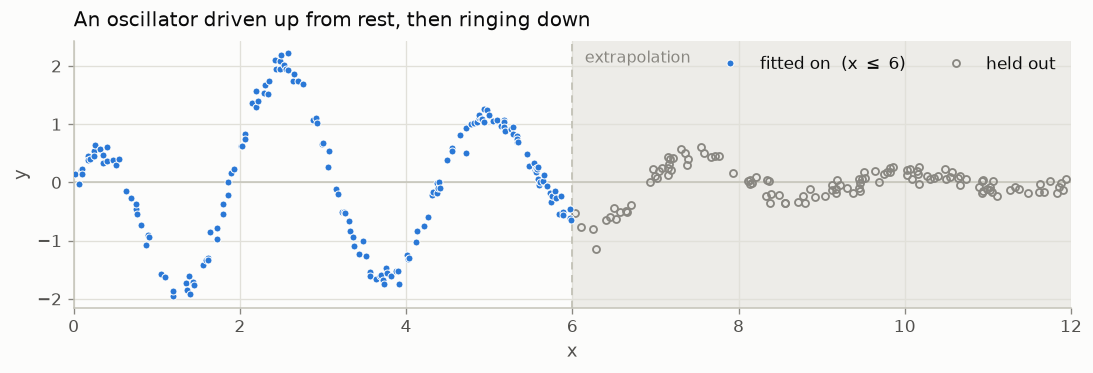

In [9]:
x_fit, y_fit, x_out, y_out = oscillator_data()
X_fit = x_fit.reshape(-1, 1)

print(f"{len(x_fit)} points to fit on, {len(x_out)} held back")
plot_oscillator_data(x_fit, y_fit, x_out, y_out)

### The plain API

Lets review again the API for PySR. 

**The tool — the estimator itself**

```python
model = PySRRegressor(
    binary_operators=["+", "-", "*", "/"],   # two-argument operators
    unary_operators=["sin", "cos", "exp"],   # one-argument operators
    maxsize=25,                              # node budget for one expression
    niterations=40,                          # how long the populations evolve
)
model.fit(X, y, variable_names=["x"])        # X is (n_samples, n_features)
```

`model.equations_` is the Pareto front, one row per complexity. 

`model.get_best()` returns a single row from it, and `model.predict(X)` uses that row unless you pass `index=`.

In [16]:
t = time.time()

unconstrained = PySRRegressor(
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["sin", "cos", "exp", "log", "sqrt"],
    maxsize=25,          # largest expression the search may build
    niterations=40,      # how long the populations get to evolve
    **REPRO
)
unconstrained.fit(X_fit, y_fit, variable_names=["x"])

unconstrained.equations_[["complexity", "loss", "score", "equation"]]

,complexity,loss,score,equation
0,1,1.130147,0.000000,0.052869614
1,3,1.124485,0.002511,x * 0.024732327
2,4,0.238257,1.551731,cos(x * 2.5000575)
3,6,0.149426,0.233273,cos(x / -0.40026066) / 0.699377
4,8,0.138035,0.039648,(cos(x / -0.40132996) / 0.6871598) + -0.11181744
5,9,0.061149,0.814199,cos(x / -0.4003641) / cos(sin(sqrt(x)))
6,11,0.052845,0.072971,cos(x / -0.39981374) / cos(sin(sqrt(x) * 1.087...
7,12,0.044863,0.163755,cos(x / -0.40036437) / exp(sin(x / 1.6541892) ...
8,13,0.044830,0.000727,cos(x / -0.40031573) / exp(sin(sin(x / 1.65250...
9,14,0.034591,0.259304,cos(x / -0.40077853) / exp(cos(sqrt(x) + sin(x...


In [17]:
X_fit.shape
# just one feature here, so we need one name for vairable

(180, 1)

`get_best()` is the row PySR would hand us if we asked for one model: the steepest drop in loss among the rows that are still close to the best fit.

cos(x / -0.40026835) / exp((cos(x + cos(-0.40026835 * x)) / sqrt(x)) - 0.07151579)
nested trig on 7 rows


<lambdifygenerated-1>:2: RuntimeWarning: divide by zero encountered in divide
  return 1.07413511116082*exp(-cos(x + cos(0.40026835*x))/sqrt(x))*cos(2.49832393692881*x)


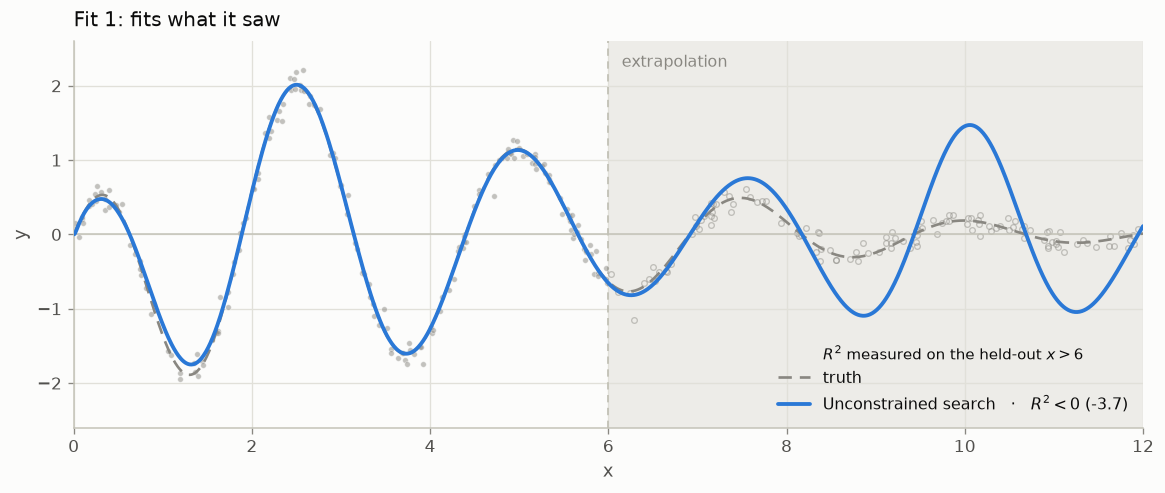

In [18]:
print(unconstrained.get_best().equation)
print(f"nested trig on {unconstrained.equations_.equation.map(has_nested_trig).sum()} rows")

plot_fits([("Unconstrained search", unconstrained)], x_fit, y_fit, x_out, y_out,
          title="Fit 1: fits what it saw")

Do you see any 'problems' with this solution? What would you do to improve it?

### Constraints

Some of the expressions in the front also have expressions with a cosine wrapped inside another cosine. `nested_constraints` says which function may appear inside which, for every expression the search passes through rather than only the survivors.


**The tool — `nested_constraints`**

```python
PySRRegressor(nested_constraints={"cos": {"cos": 0, "exp": 1}}, ...)
```

Read it as: anywhere inside a `cos`, allow zero `cos` and at most one `exp`, at any depth below. Operators you leave out stay unrestricted.

This is a rule about the search space, so it applies to every candidate ever built, not just the ones that survive to the front.

In [19]:
no_nesting = dict(
    nested_constraints={
        "sin": {"sin": 0, "cos": 0},     # no trig inside trig
        "cos": {"sin": 0, "cos": 0},
        "exp": {"exp": 0},
        "log": {"log": 0, "exp": 0},
        "sqrt": {"sqrt": 0},
    },
)

t = time.time()
tidy = PySRRegressor(
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["sin", "cos", "exp", "log", "sqrt"],
    maxsize=25, niterations=40, random_state=3, **no_nesting, **REPRO,
)
tidy.fit(X_fit, y_fit, variable_names=["x"])

print(f"{time.time() - t:.0f}s   {len(tidy.equations_)} rows "
      f"(was {len(unconstrained.equations_)}), "
      f"nested trig on {tidy.equations_.equation.map(has_nested_trig).sum()}")
tidy.equations_[["complexity", "loss", "score", "equation"]]

13s   12 rows (was 13), nested trig on 0


,complexity,loss,score,equation
0,1,1.130147,0.000000,0.052869584
1,3,1.124484,0.002511,x * 0.024730865
2,4,0.238257,1.551731,cos(x * 2.5000381)
3,6,0.149426,0.233273,cos(x * 2.4983952) * 1.4297473
4,8,0.138034,0.039650,(cos(x * 2.4918323) - 0.07639524) * 1.455988
5,10,0.127599,0.039307,cos(x * 2.49938) / ((0.41918913 / x) + 0.50138...
6,11,0.091451,0.333089,cos((x * 1.4942656) + x) * (1.376588 - cos(x))
7,12,0.017430,1.657595,cos(x * 2.49938) / (((2.6711376 / x) + x) / 6....
8,14,0.015485,0.059182,cos(x * 2.498366) / (((3.0739367 / x) + (x + -...
9,16,0.012633,0.101765,cos(x * 2.4984248) / (((0.95886344 / x) / 1.82...


<lambdifygenerated-3>:2: RuntimeWarning: divide by zero encountered in divide
  return 1.07413511116082*exp(-cos(x + cos(0.40026835*x))/sqrt(x))*cos(2.49832393692881*x)
<lambdifygenerated-5>:2: RuntimeWarning: divide by zero encountered in divide
  return cos(2.4984248*x)/(x/(11.482092 - x) + 0.95886344/(1.8287673*x))


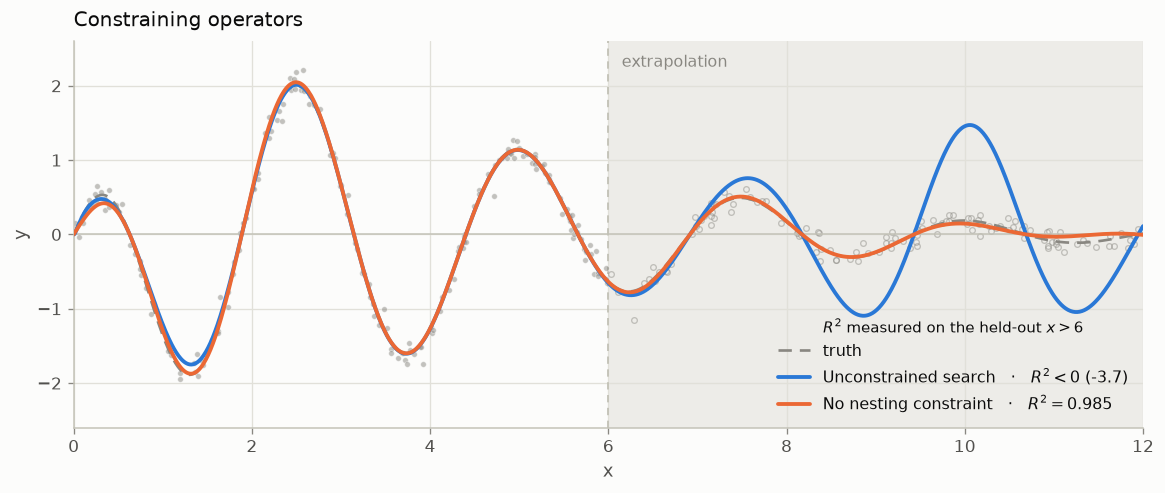

In [20]:
plot_fits([("Unconstrained search", unconstrained), ("No nesting constraint", tidy)],
          x_fit, y_fit, x_out, y_out, title="Constraining operators")

Found faster, with the unphysical terms not appearing.

### The right basis function

We can also bias the search by giving it a basis of functions that we know are physically relevant.

11s   cos(((x / -0.5936495) / (x * 0.6742031)) * x) * (exp((x * -0.49630603) + 1.0186702) * x)


<lambdifygenerated-7>:2: RuntimeWarning: divide by zero encountered in divide
  return 1.07413511116082*exp(-cos(x + cos(0.40026835*x))/sqrt(x))*cos(2.49832393692881*x)
<lambdifygenerated-9>:2: RuntimeWarning: divide by zero encountered in divide
  return cos(2.4984248*x)/(x/(11.482092 - x) + 0.95886344/(1.8287673*x))
<lambdifygenerated-11>:2: RuntimeWarning: invalid value encountered in divide
  return x*exp(1.0186702 + (-0.49630603)*x)*cos(x*x/((-0.5936495)*((0.6742031*x))))


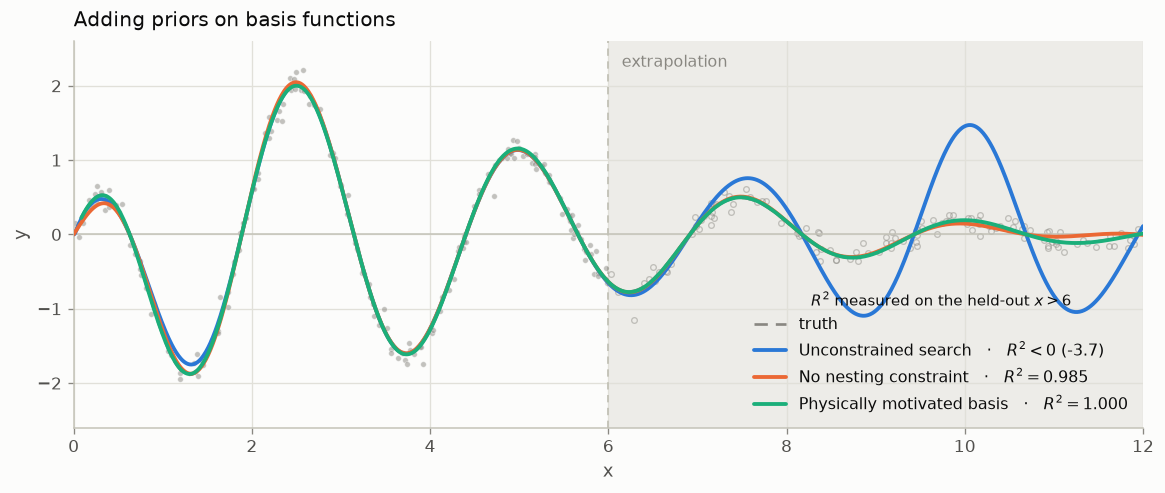

In [21]:
t = time.time()
basis = PySRRegressor(
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["cos", "exp"],          # one oscillation, one envelope, nothing else
    maxsize=25, niterations=40, random_state=3, **REPRO,
    nested_constraints={"cos": {"cos": 0}, "exp": {"exp": 0}},
)
basis.fit(X_fit, y_fit, variable_names=["x"])

print(f"{time.time() - t:.0f}s   {basis.get_best().equation}")
plot_fits([("Unconstrained search", unconstrained), ("No nesting constraint", tidy), ("Physically motivated basis", basis)],
          x_fit, y_fit, x_out, y_out, title="Adding priors on basis functions")

There it is: $2.8\,x\,e^{-x/2}\cos(2.5x)$, which is the ground truth... (set by me, but the search does not know that).

### Physics in the loss instead

Suppose we only knew it is *damped*... And that is a property of the whole function, not just one point.

`elementwise_loss` sees one point at a time, so it cannot express that. `loss_function`: it gets the tree and can evaluate it anywhere we like, including on $x$ far outside the data... so we can use this to penalize functions that do not decay at large $x$.

**The tool — `loss_function`**

```python
LOSS = """
function my_loss(tree, dataset::Dataset{T,L}, options)::L where {T,L}
    prediction, ok = eval_tree_array(tree, dataset.X, options)
    !ok && return L(Inf)                     # candidate failed to evaluate
    return sum((prediction .- dataset.y).^2) / dataset.n
end
"""
PySRRegressor(loss_function=LOSS, ...)
```

This one is handed the whole candidate tree, so `eval_tree_array` can evaluate it on any inputs we like, not only the data.

In [22]:
DECAY_LOSS = """
function decay_loss(tree, dataset::Dataset{T,L}, options)::L where {T,L}
    prediction, ok = eval_tree_array(tree, dataset.X, options)
    !ok && return L(Inf)
    mse = sum((prediction .- dataset.y).^2) / dataset.n

    far = reshape(T.(collect(12.0:1.0:30.0)), 1, :)
    tail, ok_far = eval_tree_array(tree, far, options)
    !ok_far && return L(Inf)

    return mse + sum(tail.^2) / length(tail)
end
"""

We put the wide operator set back — `log`, `sqrt` and all — so the only thing helping is the loss.

13s   (x * cos(x * 2.4985664)) * exp(1.0211947 - (x * 0.4972508))


<lambdifygenerated-19>:2: RuntimeWarning: divide by zero encountered in divide
  return 1.07413511116082*exp(-cos(x + cos(0.40026835*x))/sqrt(x))*cos(2.49832393692881*x)
<lambdifygenerated-21>:2: RuntimeWarning: invalid value encountered in divide
  return x*exp(1.0186702 + (-0.49630603)*x)*cos(x*x/((-0.5936495)*((0.6742031*x))))
<lambdifygenerated-25>:2: RuntimeWarning: divide by zero encountered in divide
  return cos(2.4984248*x)/(x/(11.482092 - x) + 0.95886344/(1.8287673*x))


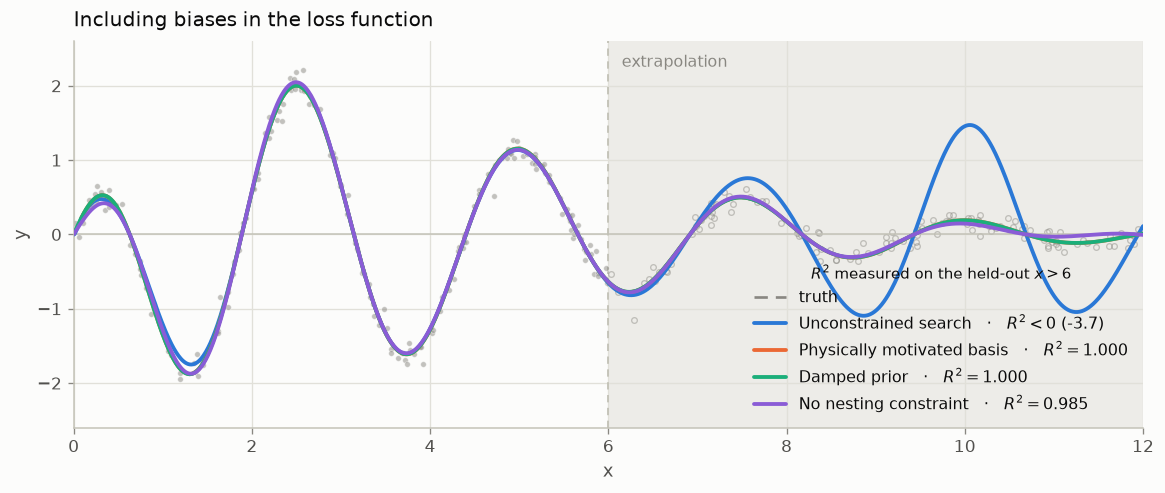

In [24]:
t = time.time()
damped = PySRRegressor(
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["cos", "exp", "log", "sqrt"],
    maxsize=25, niterations=40, random_state=3,
    loss_function=DECAY_LOSS, **REPRO,
)
damped.fit(X_fit, y_fit, variable_names=["x"])

print(f"{time.time() - t:.0f}s   {damped.get_best().equation}")
plot_fits([("Unconstrained search", unconstrained), ("Physically motivated basis", basis), ("Damped prior", damped),  ("No nesting constraint", tidy)],
          x_fit, y_fit, x_out, y_out, title="Including biases in the loss function")

Never told which envelope to use, and it still lands on $\approx 2.8\,x\,e^{-x/2}\cos(2.5x)$ — spelled `x * 2.8 * cos(2.5x) / sqrt(exp(x))`, since $\sqrt{e^{x}}$...

In [25]:
x_bad, y_bad, x_out, y_out = oscillator_data(outliers=True)
X_bad = x_bad.reshape(-1, 1)

squared = PySRRegressor(
    binary_operators=["+", "-", "*", "/"], unary_operators=["sin", "cos", "exp", "log", "sqrt"],
    maxsize=25, niterations=40, random_state=3, **REPRO,
)
squared.fit(X_bad, y_bad, variable_names=["x"])
print(f"{squared.get_best().equation}")

(1.461573 - sin(x - 4.1713295)) * sin((x * 2.5304058) - -1.4957159)


Lets try another 'trick' to see how we can bias the search to be robust to noise. Instead of the usual squared error, we can use a Huber loss, which is quadratic for small residuals but linear for large ones. This way, outliers do not dominate the loss and the search is more robust to noise.

18s   (sin((x * -2.504439) + 1.5860354) * (2.7925987 / exp(x * 0.4989055))) * x


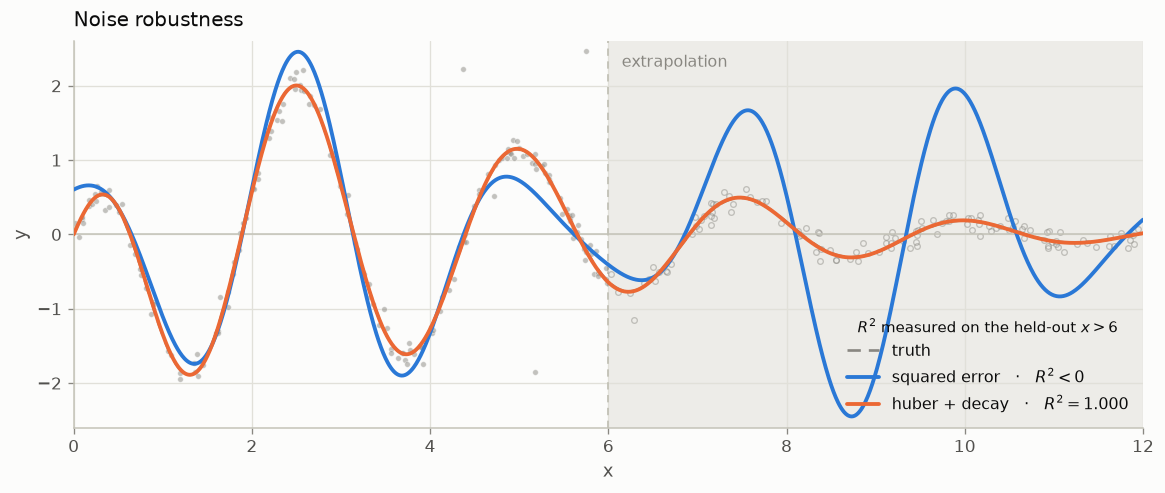

In [26]:
ROBUST_LOSS = """
function robust_loss(tree, dataset::Dataset{T,L}, options)::L where {T,L}
    prediction, ok = eval_tree_array(tree, dataset.X, options)
    !ok && return L(Inf)

    d = abs.(prediction .- dataset.y)
    delta = L(0.3)                       # beyond this a residual is an outlier, not noise
    huber = sum(ifelse.(d .< delta, L(0.5) .* d.^2, delta .* (d .- L(0.5) * delta))) / dataset.n

    far = reshape(T.(collect(12.0:1.0:30.0)), 1, :)
    tail, ok_far = eval_tree_array(tree, far, options)
    !ok_far && return L(Inf)

    return huber + sum(tail.^2) / length(tail)
end
"""

t = time.time()
robust = PySRRegressor(
    binary_operators=["+", "-", "*", "/"], unary_operators=["sin", "cos", "exp"],
    maxsize=25, niterations=40, random_state=3,
    loss_function=ROBUST_LOSS, **REPRO,
    nested_constraints={"sin": {"sin": 0, "cos": 0}, "cos": {"sin": 0, "cos": 0},
                        "exp": {"exp": 0}},
)
robust.fit(X_bad, y_bad, variable_names=["x"])
print(f"{time.time() - t:.0f}s   {robust.get_best().equation}")

plot_fits([("squared error", squared), ("huber + decay", robust)],
          x_bad, y_bad, x_out, y_out, title="Noise robustness")

Same data, same operators, same budget. The only difference is what we told it to minimise.

Three places to put what we know, then: the operators the search may use, the shapes it may build from them, and the number it is trying to make small. The rest of this notebook is that last one, pushed further.

---

## 2. Kepler's third law

Miles told us how the Third Law of Kepler is itself a human-made symbolic regression... Lets see this case.

Lets use the data of the solar system to see if we can recover Kepler's third law.


In [27]:
bodies, a_au, T_yr = kepler_data()
A = a_au.reshape(-1, 1)

kepler_kw = dict(binary_operators=["+", "-", "*", "/"], unary_operators=["sqrt"],
                 niterations=30, maxsize=25, random_state=2, **REPRO)

t = time.time()
mse_fit = PySRRegressor(**kepler_kw)
mse_fit.fit(A, T_yr, variable_names=["a"])
print(f"{time.time() - t:.0f}s   selected: {mse_fit.get_best().equation}")
error_table(mse_fit, "MSE").head(4)   # the rest is in the figure below

7s   selected: ((a + 0.09224464) * ((sqrt(a) - 0.034369785) * 1.0029196)) + -0.055038434


,body,a [AU],T [yr],MSE pred,MSE rel err %
0,Mercury,0.3871,0.2408,0.2275,5.505
1,Venus,0.7233,0.6152,0.6125,0.444
2,Earth,1.0000,1.0000,1.0027,0.275
3,Mars,1.5237,1.8808,1.8898,0.477


Sedna's period is forty-seven thousand times Mercury's, so squared residuals out there swamp everything inside Jupiter's orbit.

In [28]:
mse_exact = np.mean((a_au ** 1.5 - T_yr) ** 2)                # Kepler: T = a^(3/2)
mse_chosen = np.mean((mse_fit.predict(A) - T_yr) ** 2)
print(f"MSE of T = a^1.5        : {mse_exact:12.5f}")
print(f"MSE of the fitted model : {mse_chosen:12.5f}   ({mse_exact / mse_chosen:,.0f}x lower)")
print()
print(f"T = a^1.5 misses Sedna by   {100 * abs(a_au[-1] ** 1.5 - T_yr[-1]) / T_yr[-1]:.2f}%")
print(f"T = a^1.5 misses Mercury by {100 * abs(a_au[0] ** 1.5 - T_yr[0]) / T_yr[0]:.2f}%")

MSE of T = a^1.5        :     26.44008
MSE of the fitted model :      0.00021   (124,552x lower)

T = a^1.5 misses Sedna by   0.16%
T = a^1.5 misses Mercury by 0.02%


Kepler's law reproduces Sedna to a sixth of a percent, and that residual of a few years is enough for MSE to rank the actual law five orders of magnitude worse than a rational function bent around the outer bodies. We care about fractional error; MSE isn't measuring it.

The log-ratio loss from the docs does. The sign term stops the search flipping sign to game the logarithm.

**The tool — `elementwise_loss`**

```python
PySRRegressor(elementwise_loss="l(prediction, target) = (prediction - target)^2", ...)
```

One residual at a time; PySR sums it for us. The string is Julia, so `^` is exponentiation, `abs`/`log`/`sign` are builtins, and `if/else` is allowed.

Reach for this when the change is per-point, and for `loss_function` when it is not.

In [30]:
# This string is Julia rather than Python: ^ is exponentiation and sign() is a builtin.
log_loss = """function loss_fnc(prediction, target)
    scatter_loss = abs(log((abs(prediction)+1e-20) / (abs(target)+1e-20)))
    sign_loss = 10 * (sign(prediction) - sign(target))^2
    return scatter_loss + sign_loss
end"""

t = time.time()
log_fit = PySRRegressor(elementwise_loss=log_loss, **kepler_kw)
log_fit.fit(A, T_yr, variable_names=["a"])
print(f"{time.time() - t:.0f}s   selected: {log_fit.get_best().equation}")
print(f"kink row:  {kink(log_fit).equation}   (score {kink(log_fit).score:.1f})")
error_table(log_fit, "log").head(4)   # same four bodies, for the contrast

6s   selected: sqrt((a * ((0.22841166 / ((-1327.1991 / (a * sqrt(a))) - -0.2606557)) + a)) * a)
kink row:  a * sqrt(a)   (score 7.8)


,body,a [AU],T [yr],log pred,log rel err %
0,Mercury,0.3871,0.2408,0.2408,0.013
1,Venus,0.7233,0.6152,0.6151,0.016
2,Earth,1.0000,1.0000,0.9999,0.009
3,Mars,1.5237,1.8808,1.8806,0.009


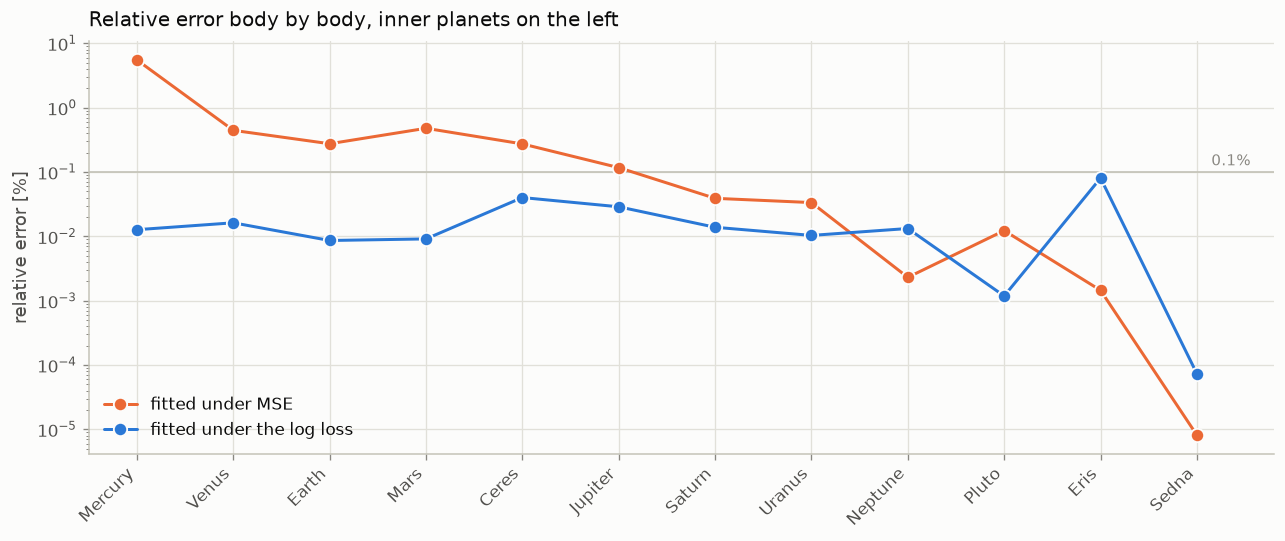

In [31]:
plot_kepler(mse_fit, log_fit)

The two fits are indistinguishable on log-log axes, so the figure shows fractional error instead. MSE trades the inner planets away for the outer ones; the log fit sits within a few hundredths of a percent throughout. The elbow row is `a * sqrt(a)`, which is $a^{3/2}$.

For plain relative error, divide by the target, never the prediction: dividing by the prediction lets evolution win by sending predictions to infinity.

In [32]:
t = time.time()
rel_fit = PySRRegressor(
    elementwise_loss="rel(prediction, target) = ((prediction - target) / target)^2",
    **kepler_kw)
rel_fit.fit(A, T_yr, variable_names=["a"])
print(f"{time.time() - t:.0f}s")
rel_fit.equations_[["complexity", "loss", "score", "equation"]].head(4)

6s


,complexity,loss,score,equation
0,1,4.185899e-01,0.000000,a
1,3,3.934291e-01,0.030995,a + -0.11927078
2,4,3.131547e-07,14.043714,a * sqrt(a)
3,6,3.092893e-07,0.006210,(-8.859119e-5 + sqrt(a)) * a


In [33]:
rel_best = rel_fit.get_best()
rel_best_sympy = sympy.sympify(rel_best.equation)
rel_best_sympy

a*(sqrt(a) + a*(2.6018432e-7*a - 6.250641e-5))

## 3. Spring-mass energy, and templates

Lets look at a simple example of a spring-mass system. The energy of the system is given by the sum of the kinetic and potential energies:

$E(x, v) = \tfrac12 k x^2 + \tfrac12 m v^2$ separates into a function of $x$ plus a function of $v$... but no-one has told PySR what the answer looks like.

**The tool — `TemplateExpressionSpec`**

```python
spec = TemplateExpressionSpec(
    "f(x) + g(v)",               # the fixed shape; f and g are the holes
    expressions=["f", "g"],      # what the search is allowed to fill in
    variable_names=["x", "v"],   # names, in the order of X's columns
)
PySRRegressor(expression_spec=spec, ...)
```

The algebra around the holes is structure, not a hypothesis: no candidate can trade it away. Components print with `#1` for their first argument.

In [35]:
x_1, v_1, E_1 = single_rig()

separable = TemplateExpressionSpec("f(x) + g(v)", expressions=["f", "g"],
                                   variable_names=["x", "v"])

warmup = PySRRegressor(expression_spec=separable, binary_operators=["+", "-", "*"],
                       maxsize=20, niterations=20, random_state=40, **REPRO)
warmup.fit(np.column_stack([x_1, v_1]), E_1, variable_names=["x", "v"])
print(f"kink: {kink(warmup).equation}")
warmup.equations_[["complexity", "loss", "score", "equation"]]

kink: f = (#1 * #1) * 2.0; g = #1 * (#1 * 0.75)


,complexity,loss,score,equation
0,2,2.633620e+00,0.000000,f = 1.5577768; g = 0.9169168
1,4,1.271074e+00,0.364248,f = #1 * #1; g = 1.7423912
2,6,6.646108e-01,0.324208,f = #1 * #1; g = #1 * #1
3,8,1.337377e-01,0.801660,f = (#1 * #1) * 1.7383113; g = #1 * #1
4,10,2.517322e-14,14.650561,f = (#1 * #1) * 2.0; g = #1 * (#1 * 0.75)
5,12,2.400943e-14,0.023667,f = #1 * (#1 * 2.0); g = (#1 * (#1 * 0.75)) - ...
6,14,2.286396e-14,0.024442,f = (#1 * (#1 * 2.0)) + -3.0202482e-8; g = ((#...


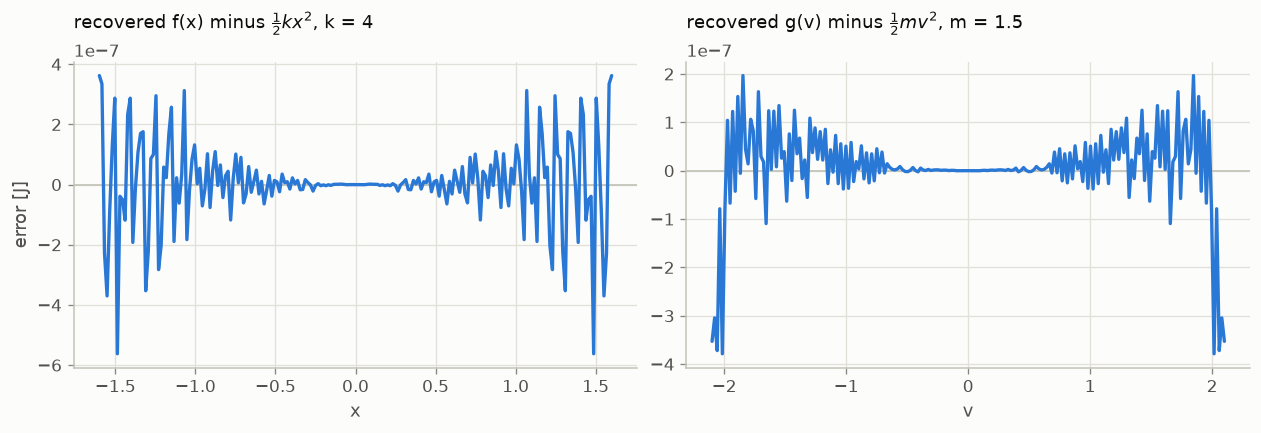

In [37]:
# f and g come back out by slicing the fitted surface: E(x, 0) is f, and E(0, v) is g.
plot_components(warmup, x_1, v_1)

`#1` is the component's first argument. 

The elbow row gives $f(x) = 2x^2$ and $g(v) = 0.75v^2$, which are $\tfrac12 k$ and $\tfrac12 m$ for $k = 4$, $m = 1.5$.

---

## Distilling a network we already trained

As many of you have seen, a neural network can be trained to fit a function, but it is often hard to interpret what the network has learned.

There is this very nice idea of distilling a network into a symbolic expression, and we can do that with PySR.

**The tool — SymTorch**

```python
net.mlp = SymbolicModel(net.mlp, block_name="Sequential")   # wraps in place
fits = net.mlp.distill(X, parent_model=net, sr_params=SR_PARAMS)
net.mlp.switch_to_symbolic(complexity=[9])   # the equation now runs in forward()
net.mlp.switch_to_block()                    # and back to the network
```

`distill` returns one `PySRRegressor` per output of the wrapped block.

In [39]:
import importlib

In [40]:
if importlib.util.find_spec("symtorch") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch-symbolic"], check=True)

import torch
import torch.nn as nn
from symtorch import SymbolicModel

print(f"torch {torch.__version__}, symtorch imported")
print("DEFAULT_SR_PARAMS niterations =", SymbolicModel.DEFAULT_SR_PARAMS["niterations"])

torch 2.13.0+cpu, symtorch imported
DEFAULT_SR_PARAMS niterations = 400


In [41]:
SR_PARAMS = dict(binary_operators=["+", "*", "/"], unary_operators=[], niterations=30,
                 deterministic=True, parallelism="serial", random_state=6,
                 verbosity=0, progress=False)

t = time.time()
_prewarm = SymbolicModel(nn.Sequential(nn.Linear(1, 4), nn.ReLU(), nn.Linear(4, 1)),
                         block_name="prewarm")
_ = _prewarm.distill(torch.randn(30, 1), save_path="symtorch_runs",
                     sr_params={**SR_PARAMS, "niterations": 2})
print(f"first .distill(): {time.time() - t:.0f}s")

first .distill(): 3s


Lets use the same spring-mass system as before, but this time we will train a neural network to fit the data and then distill it into a symbolic expression.

In [42]:
RECOVER = False        # flip to True to load assets/problem6_mlp.pt instead of training


class ForceNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(2, 32), nn.ReLU(),
                                 nn.Linear(32, 32), nn.ReLU(),
                                 nn.Linear(32, 1))

    def forward(self, x):
        return self.mlp(x)


X_tr, y_tr = force_law_data(400, seed=6)
X_te, y_te = force_law_data(400, seed=7)
X_tr_t, y_tr_t = torch.tensor(X_tr), torch.tensor(y_tr)
X_te_t, y_te_t = torch.tensor(X_te), torch.tensor(y_te)

torch.manual_seed(6)
net = ForceNet()

if RECOVER and (ASSETS / "problem6_mlp.pt").exists():
    net.load_state_dict(
        torch.load(ASSETS / "problem6_mlp.pt", weights_only=False)["state_dict"])
    print("loaded assets/problem6_mlp.pt instead of training")
else:
    if RECOVER:
        print("RECOVER=True but assets/problem6_mlp.pt is missing, so training instead")
    opt = torch.optim.Adam(net.parameters(), lr=1e-2)
    for _ in range(400):
        opt.zero_grad()
        train_loss = nn.functional.mse_loss(net(X_tr_t), y_tr_t)
        train_loss.backward()
        opt.step()
    print(f"trained 400 epochs: train mse {train_loss.item():.3e}")

with torch.no_grad():
    mlp_mse = nn.functional.mse_loss(net(X_te_t), y_te_t).item()
print(f"MLP held-out test mse {mlp_mse:.3e}")

trained 400 epochs: train mse 3.804e-04
MLP held-out test mse 6.000e-04


Wrapping replaces the submodule in place, so the network keeps working and now also describes itself. `net.mlp.show_symbolic_expression()` prints the front per output dimension.

In [43]:
net.mlp = SymbolicModel(net.mlp, block_name="Sequential")

t = time.time()
distilled = net.mlp.distill(X_tr_t, parent_model=net, sr_params=SR_PARAMS,
                            save_path="symtorch_runs")
print(f"distill: {time.time() - t:.0f}s")
distilled[0].equations_[["complexity", "loss", "score", "equation"]]

distill: 9s


,complexity,loss,score,equation
0,1,0.761717,0.000000,0.98311585
1,3,0.209604,0.645178,1.2424847 / x0
2,5,0.029682,0.977332,1.0047041 / (x0 * x0)
3,7,0.029617,0.001108,(1.0119812 / (x0 * x0)) + -0.012438968
4,9,0.000377,2.181808,(0.29992366 * x1) + ((0.99919957 / x0) / x0)
5,11,0.000353,0.032626,(x1 * 0.30025005) + (1.0088162 / ((x0 * x0) + ...
6,19,0.000341,0.004257,(((x0 * 0.20565808) * x1) + ((-0.41803992 / ((...
7,21,0.000334,0.010827,((-0.49497098 / (x0 / -1.7198335)) + (((x0 * x...
8,23,0.000294,0.063400,(((-0.9914701 / x0) / -1.6160977) + (((x1 * x0...
9,25,0.000277,0.030887,(((x0 * ((x0 / (((x0 * x0) * x0) + 0.048983924...


Now we take the elbow row and swap it in for the network.

In [44]:
pick = int(kink(distilled[0]).complexity)
net.mlp.switch_to_symbolic(complexity=[pick])

with torch.no_grad():
    sym_pred = net(X_te_t).numpy()
    sym_mse = nn.functional.mse_loss(net(X_te_t), y_te_t).item()

print(f"swapped in complexity {pick}: {kink(distilled[0]).equation}")
print(f"MLP      test mse: {mlp_mse:.3e}")
print(f"symbolic test mse: {sym_mse:.3e}   ({mlp_mse / sym_mse:,.0f}x lower)")

swapped in complexity 9: (0.29992366 * x1) + ((0.99919957 / x0) / x0)
MLP      test mse: 6.000e-04
symbolic test mse: 1.120e-06   (536x lower)


back on the network: 6.000e-04


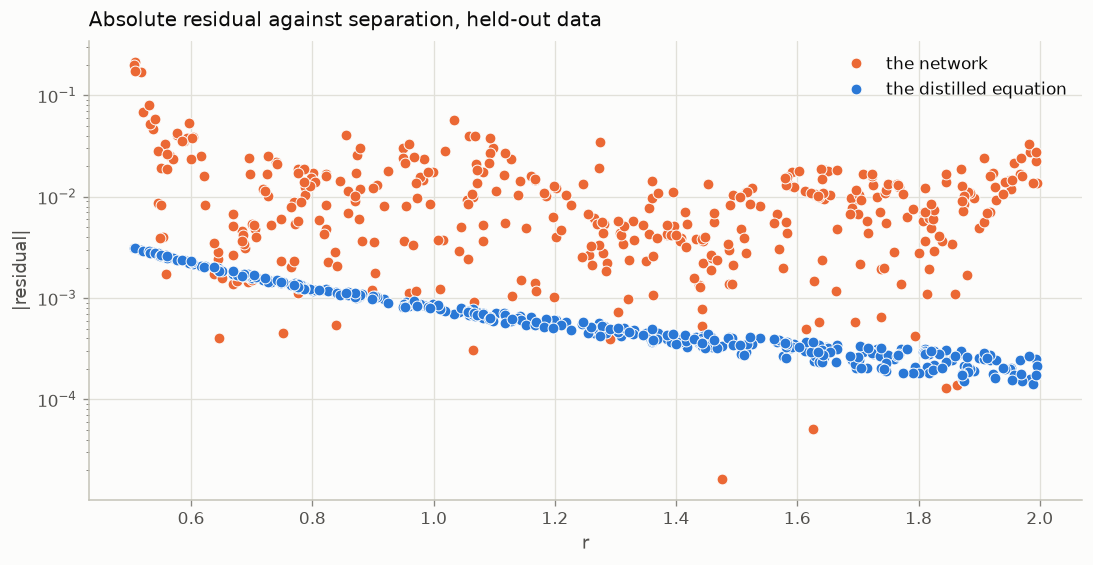

In [45]:
net.mlp.switch_to_block()          # restores the network exactly, not switch_to_mlp
with torch.no_grad():
    mlp_pred = net(X_te_t).numpy()
    print(f"back on the network: {nn.functional.mse_loss(net(X_te_t), y_te_t).item():.3e}")

plot_distillation(X_te, y_te, mlp_pred, sym_pred)

The equation beats the network it came from on held-out data by better than two orders of magnitude. The network built $1/r^2$ out of ReLUs and carried that error into every prediction; the equation simply is $1/r^2$, so distillation threw the interpolation error away along with the 1,185 parameters.

## Where that leaves us

Every target this afternoon had a known answer, which is the only way to tell whether a prior helped or merely changed something.